In [1]:
import pandas as pd
import glob
import json
import os

sample_path = f'{os.getcwd()}/../workspace/samples/'

x86_samples = 'x86-gemini-pro'
arm_samples = 'arm-gemini-pro'

def get_rows(path):

    summaries = sorted(glob.glob(f'{path}/*/agent_repair/summary.json'))

    rows = []
    for sample, path in enumerate(summaries):

        with open(path, 'r') as f:
            data = json.load(f)
        
        arch = data['summary']['arch']
        model = data['models']['llm']

        for attempt in data['attempts']:
            rows.append({
            'sample': sample,
            'arch': arch,
            'model': model,
            'attempt': attempt['attempt'],
            'boot_succeeded': attempt['summary']['boot_succeeded'],
            'define': attempt['changes']['define'],
            'undefine': attempt['changes']['undefine'],
            'original_config': f'{os.path.dirname(path)}/../.config',
            'modified_config': f'{os.path.dirname(path)}/attempt_{attempt["attempt"]}/modified.config',
            'total_constraints': data['summary']['total_constraints'],
        })

    return rows

rows = get_rows(f'{sample_path}/{x86_samples}') + get_rows(f'{sample_path}/{arm_samples}')
df = pd.DataFrame(rows)

print(df.groupby('model')['sample'].nunique())

df.head()

model
gemini-3.1-pro-preview    50
Name: sample, dtype: int64


,sample,arch,model,attempt,boot_succeeded,define,undefine,original_config,modified_config,total_constraints
0,0,x86_64,gemini-3.1-pro-preview,0,no,None,None,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,79
1,0,x86_64,gemini-3.1-pro-preview,1,timeout,[],[CONFIG_KASAN],/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,79
2,0,x86_64,gemini-3.1-pro-preview,2,panic,"[CONFIG_TTY, CONFIG_SERIAL_8250, CONFIG_SERIAL...",[CONFIG_KASAN],/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,79
3,0,x86_64,gemini-3.1-pro-preview,3,timeout,[],"[CONFIG_KASAN, CONFIG_KCSAN]",/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,79
4,0,x86_64,gemini-3.1-pro-preview,4,panic,"[CONFIG_TTY, CONFIG_SERIAL_8250, CONFIG_SERIAL...","[CONFIG_KASAN, CONFIG_KCSAN]",/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,79


In [2]:
def parse_config(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    options = set()

    for line in lines:
        if '=' in line:
            options.add(line.strip().split('=')[0])
            
    return options

def jaccard_similarity(a, b):
    return len(a & b) / len(a | b) if a | b else 1.0

In [3]:
import numpy as np

repaired_samples = df[df['boot_succeeded'] == 'yes']

def get_before_after_similarities(samples):

    num_samples = samples['sample'].nunique()

    before = np.zeros((num_samples, num_samples))
    after = np.zeros((num_samples, num_samples))

    for i, a in enumerate(samples['sample'].unique()):
        for j, b in enumerate(samples['sample'].unique()):

            if i > j:
                continue

            config_a_before = parse_config(samples[samples['sample'] == a]['original_config'].iloc[0])
            config_b_before = parse_config(samples[samples['sample'] == b]['original_config'].iloc[0])
            score = jaccard_similarity(config_a_before, config_b_before)
            
            before[i, j] = score
            before[j, i] = score

            config_a_after = parse_config(samples[samples['sample'] == a]['modified_config'].iloc[0])
            config_b_after = parse_config(samples[samples['sample'] == b]['modified_config'].iloc[0])
            score = jaccard_similarity(config_a_after, config_b_after)
            
            after[i, j] = score
            after[j, i] = score

    return before, after

In [4]:
x86_before, x86_after = get_before_after_similarities(repaired_samples[repaired_samples['arch'] == 'x86_64'])
arm_before, arm_after = get_before_after_similarities(repaired_samples[repaired_samples['arch'] == 'arm64'])

x86_sample_similarity = pd.DataFrame({
    'before': x86_before[np.triu_indices_from(x86_before, k=1)],
    'after': x86_after[np.triu_indices_from(x86_after, k=1)]
})

print('x86 Sample Similarity:')
print(x86_sample_similarity.describe())

arm_sample_similarity = pd.DataFrame({
    'before': arm_before[np.triu_indices_from(arm_before, k=1)],
    'after': arm_after[np.triu_indices_from(arm_after, k=1)]
})

print('\n\nARM Sample Similarity:')
print(arm_sample_similarity.describe())

x86 Sample Similarity:
           before       after
count  990.000000  990.000000
mean     0.306674    0.325459
std      0.040249    0.039233
min      0.218123    0.233551
25%      0.277032    0.296018
50%      0.303255    0.323432
75%      0.332277    0.353091
max      0.438393    0.446556


ARM Sample Similarity:
            before        after
count  1081.000000  1081.000000
mean      0.306533     0.318755
std       0.032191     0.031284
min       0.213282     0.235179
25%       0.282903     0.295899
50%       0.304710     0.319155
75%       0.328842     0.341515
max       0.416084     0.415750


In [5]:
from scipy.stats import ttest_rel

x86_t_stat, x86_p_value = ttest_rel(x86_sample_similarity['before'], x86_sample_similarity['after'])
print(f'x86: t-stat = {x86_t_stat}, p-value = {x86_p_value}')

arm_t_stat, arm_p_value = ttest_rel(arm_sample_similarity['before'], arm_sample_similarity['after'])
print(f'ARM: t-stat = {arm_t_stat}, p-value = {arm_p_value}')

x86: t-stat = -25.816594859469586, p-value = 9.240139785228254e-113
ARM: t-stat = -17.77939514773895, p-value = 3.1554037360531e-62


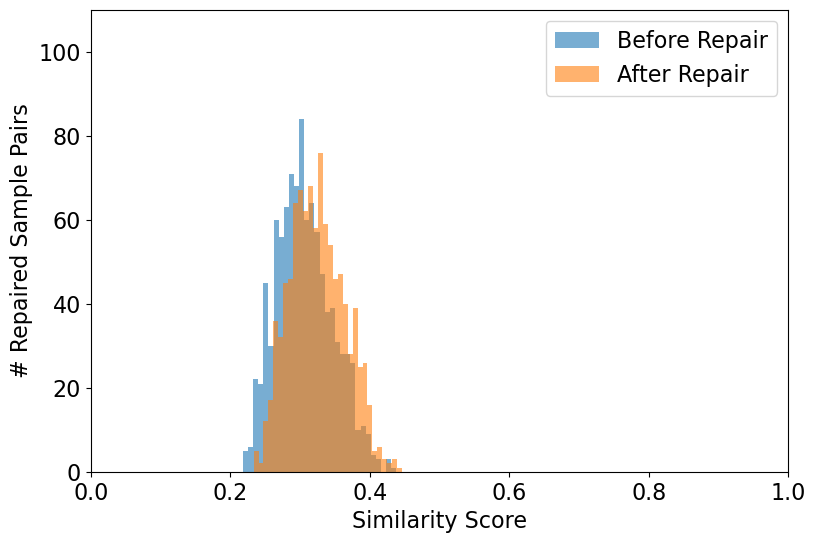

In [7]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

x86_before_vals = x86_sample_similarity['before'].values
x86_after_vals = x86_sample_similarity['after'].values

ax.hist(x86_before_vals, bins=30, alpha=0.6, label='Before Repair')
ax.hist(x86_after_vals, bins=30, alpha=0.6, label='After Repair')

ax.set_xlabel('Similarity Score', fontsize=16)
ax.set_xlim(0, 1)

ax.set_ylabel('# Repaired Sample Pairs', fontsize=16)
ax.set_ylim(0, 110)

ax.legend(fontsize=16)
ax.tick_params(axis='both', labelsize=16)

plt.savefig('x86-paired-similarity.pdf', format='pdf', bbox_inches='tight')
plt.show()

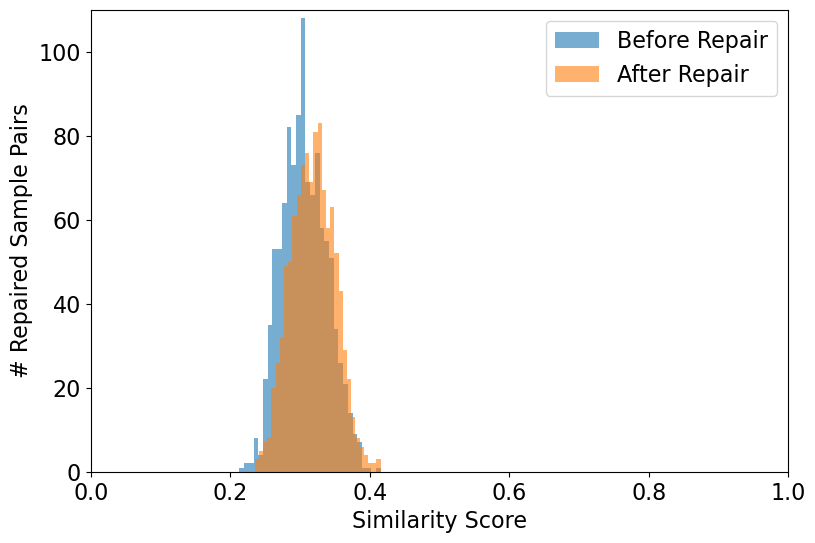

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

arm_before_vals = arm_sample_similarity['before'].values
arm_after_vals = arm_sample_similarity['after'].values

ax.hist(arm_before_vals, bins=30, alpha=0.6, label='Before Repair')
ax.hist(arm_after_vals, bins=30, alpha=0.6, label='After Repair')

ax.set_xlabel('Similarity Score', fontsize=16)
ax.set_xlim(0, 1)

ax.set_ylabel('# Repaired Sample Pairs', fontsize=16)
ax.set_ylim(0, 110)

ax.legend(fontsize=16)
ax.tick_params(axis='both', labelsize=16)

plt.savefig('arm-paired-similarity.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [9]:
from itertools import combinations

last_attempts = df[df['boot_succeeded'] == 'yes']
last_x86_attempts = last_attempts[last_attempts['arch'] == 'x86_64']
last_arm_attempts = last_attempts[last_attempts['arch'] == 'arm64']

def get_change_similarities(samples):

    rows = list(samples.itertuples())
    data = []

    for a, b in combinations(rows, 2):

        a_defines, b_defines = set(a.define), set(b.define)
        a_undefines, b_undefines = set(a.undefine), set(b.undefine)

        a_suggestions = set(a_defines) | set([f'!{opt}' for opt in a_undefines])
        b_suggestions = set(b_defines) | set([f'!{opt}' for opt in b_undefines])

        data.append({
            'define': jaccard_similarity(a_defines, b_defines),
            'undefine': jaccard_similarity(a_undefines, b_undefines),
            'suggestions': jaccard_similarity(a_suggestions, b_suggestions),
        })

    return pd.DataFrame(data)

x86_change_similarity = get_change_similarities(last_x86_attempts)
arm_change_similarity = get_change_similarities(last_arm_attempts)

print('x86 Change Similarity:')
print(x86_change_similarity.describe())

print('\n\nARM Change Similarity:')
print(arm_change_similarity.describe())

x86 Change Similarity:
           define    undefine  suggestions
count  990.000000  990.000000   990.000000
mean     0.225839    0.111470     0.175085
std      0.095881    0.078719     0.069336
min      0.000000    0.000000     0.000000
25%      0.153846    0.050956     0.123004
50%      0.219756    0.103448     0.174112
75%      0.292998    0.161146     0.224784
max      0.566038    0.440000     0.396040


ARM Change Similarity:
            define     undefine  suggestions
count  1081.000000  1081.000000  1081.000000
mean      0.247586     0.123589     0.182318
std       0.091450     0.083960     0.067549
min       0.027778     0.000000     0.027027
25%       0.182692     0.055556     0.132353
50%       0.250000     0.116279     0.182796
75%       0.304348     0.187500     0.229008
max       0.580645     0.406250     0.417722


count    990.000000
mean       0.175085
std        0.069336
min        0.000000
25%        0.123004
50%        0.174112
75%        0.224784
max        0.396040
Name: suggestions, dtype: float64


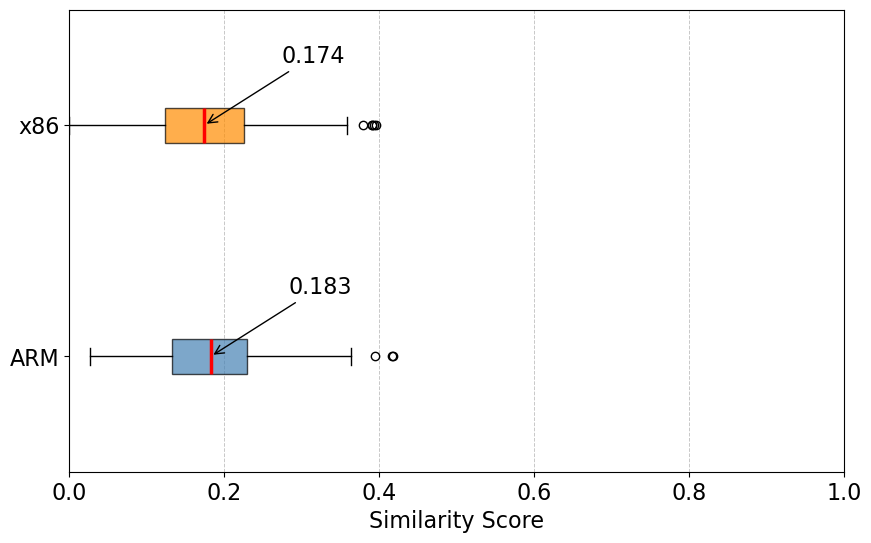

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'darkorange']

change_similarity = [arm_change_similarity['suggestions'], x86_change_similarity['suggestions']]
bp = ax.boxplot(change_similarity, labels=['ARM', 'x86'], patch_artist=True, vert=False)

print(change_similarity[1].describe())
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, median in enumerate(bp['medians']):
    median.set_color('red')
    median.set_linewidth(2.5)
    x = median.get_xdata()[1]
    y = i + 1
    ax.annotate(f'{x:.3f}', xy=(x, y), xytext=(x + 0.1, y + 0.3), fontsize=16, color='black', va='center', arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Similarity Score', fontsize=16)
ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0, 1)

plt.savefig('change-similarity-boxplot.pdf', format='pdf', bbox_inches='tight')
plt.show()